# RQ5 — Transferability: PaySim (Mobile Money) and BAF (Account-Opening Fraud)

This notebook answers **RQ5**: can the modeling approach developed on the
Credit Card dataset generalize across financial domains?

**Methodological choice:** rather than re-running the full model/strategy
grid from Section 4.2-4.3, this notebook re-applies **one fixed
configuration** - XGBoost with class weighting - to two new domains. This is
the configuration Section 4.8 identified as the preferred production choice
(near-best F1, roughly two orders of magnitude cheaper to train than Random
Forest with resampling), so testing *that specific configuration's*
transferability is the more decision-relevant question than re-optimizing
per dataset. If the thesis's model/strategy recommendation only worked on
the dataset it was tuned on, that would itself be an important finding.

**v2 update:** each strategy (`none`, `class_weight`) is now trained and
evaluated for **3 fixed seeds (0, 1, 2)** on both PaySim and BAF, matching
the repeated-seed protocol already used for the main Credit Card grid
(Table 4.1) and the Unified Experimental Protocol section, so RQ5's numbers
carry the same mean $\pm$ std reporting as the rest of the thesis instead
of a single point estimate per domain.

**Structure:**
- **Part A** - PaySim (mobile-money transactions)
- **Part B** - BAF Base variant (bank-account-opening fraud)
- **Part C** - Combined transferability table across all three domains
  (Credit Card, PaySim, BAF), using the Credit Card numbers already
  established in Chapter 4.

Each part is self-contained (mounts Drive, loads its own data) so either can
be run independently.


---
# Part A — PaySim (Mobile Money)

**Dataset:** https://www.kaggle.com/datasets/ealaxi/paysim1
Columns: `step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig,
nameDest, oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud`

`step` is simulated hours (1-744, i.e. 31 days) - used for the chronological
split, the same way `Time`/`TransactionDT` were used in the earlier
notebooks.


In [1]:
# !pip install scikit-learn xgboost matplotlib seaborn joblib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix,
)
import xgboost as xgb

sns.set_theme(style="whitegrid")

def evaluate(y_true, y_pred, y_score):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": roc_auc_score(y_true, y_score),
    }

def train_xgb(X_tr, y_tr, use_class_weight, seed=42):
    fraud_ratio = y_tr.mean()
    spw = (1 - fraud_ratio) / fraud_ratio if use_class_weight and fraud_ratio > 0 else 1
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=spw, eval_metric="aucpr",
        random_state=seed, n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    return model

## A.0 Config

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/Bicocca/Thesis code')
PAYSIM_PATH = BASE / 'data' / 'raw' / 'paysim.csv'

PAYSIM_OUTDIR = BASE / 'results' / 'paysim'
PAYSIM_FIGDIR = PAYSIM_OUTDIR / 'figures'
for p in [PAYSIM_OUTDIR, PAYSIM_FIGDIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Looking for data at:', PAYSIM_PATH)
print('Exists:', PAYSIM_PATH.exists())

# PaySim is ~6.3M rows. Set a fraction < 1.0 for a faster dev run; use 1.0
# for the real result that goes in the thesis.
PAYSIM_SAMPLE_FRAC = 1.0

Mounted at /content/drive
Looking for data at: /content/drive/MyDrive/Bicocca/Thesis code/data/raw/paysim.csv
Exists: True


## A.1 Load, inspect, and engineer balance-discrepancy features

PaySim's origin/destination balance fields make it possible to build features
that have no equivalent on the Credit Card dataset: `errorBalanceOrig` and
`errorBalanceDest` measure how inconsistent the pre/post balances are with
the stated transaction amount. A legitimate transaction's balances should
update by (approximately) the amount; a mismatch is a strong anomaly signal.
This is a direct, dataset-specific test of RQ3's feature-engineering
question in a new domain.

In [3]:
df = pd.read_csv(PAYSIM_PATH)
if PAYSIM_SAMPLE_FRAC < 1.0:
    df = df.sample(frac=PAYSIM_SAMPLE_FRAC, random_state=42).sort_values("step").reset_index(drop=True)
else:
    df = df.sort_values("step").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['isFraud'].mean()*100:.4f}%  ({df['isFraud'].sum():,} / {len(df):,})")

print("\nFraud count by transaction type (a well-documented property of this")
print("simulator is that fraud is only injected into a subset of types):")
print(df.groupby("type")["isFraud"].agg(["sum", "count"]))

# Balance-discrepancy engineered features
df["errorBalanceOrig"] = df["newbalanceOrig"] + df["amount"] - df["oldbalanceOrg"]
df["errorBalanceDest"] = df["oldbalanceDest"] + df["amount"] - df["newbalanceDest"]

le_type = LabelEncoder()
df["type_encoded"] = le_type.fit_transform(df["type"])

feature_cols = [
    "step", "type_encoded", "amount",
    "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
    "errorBalanceOrig", "errorBalanceDest",
]
print(f"\nFeatures used: {feature_cols}")

Shape: (6362620, 11)
Fraud rate: 0.1291%  (8,213 / 6,362,620)

Fraud count by transaction type (a well-documented property of this
simulator is that fraud is only injected into a subset of types):
           sum    count
type                   
CASH_IN      0  1399284
CASH_OUT  4116  2237500
DEBIT        0    41432
PAYMENT      0  2151495
TRANSFER  4097   532909

Features used: ['step', 'type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest']


## A.2 Chronological split (by `step`) and scaling

In [4]:
n = len(df)
n_test = int(n * 0.2)
n_val = int(n * 0.1)
n_train = n - n_test - n_val

train = df.iloc[:n_train]
val = df.iloc[n_train:n_train + n_val]
test = df.iloc[n_train + n_val:]

print(f"Train: {len(train):,} ({train['isFraud'].mean()*100:.4f}% fraud)")
print(f"Val:   {len(val):,} ({val['isFraud'].mean()*100:.4f}% fraud)")
print(f"Test:  {len(test):,} ({test['isFraud'].mean()*100:.4f}% fraud)")

scaler = StandardScaler()
scale_cols = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest",
              "newbalanceDest", "errorBalanceOrig", "errorBalanceDest"]

train_s, test_s = train.copy(), test.copy()
for col in scale_cols:
    train_s[col] = scaler.fit_transform(train[[col]])
    test_s[col] = scaler.transform(test[[col]])

X_train, y_train = train_s[feature_cols], train_s["isFraud"]
X_test, y_test = test_s[feature_cols], test_s["isFraud"]

Train: 4,453,834 (0.0818% fraud)
Val:   636,262 (0.0497% fraud)
Test:  1,272,524 (0.3343% fraud)


## A.3 Train XGBoost (none / class_weight) and evaluate, repeated across 3 seeds

Same two conditions used in the RQ2 IEEE-CIS notebook, for the same reason:
the full model/strategy grid was already answered in Section 4.2-4.3, and
this notebook's job is to test transfer, not re-run the whole comparison.
Following the same repeated-seed protocol used for RQ1's grid (Table 4.1),
each strategy is trained and evaluated for **seeds 0, 1, 2**, and the
per-seed results are aggregated into mean $\pm$ std, using the same
`<metric>_mean` / `<metric>_std` column convention so the results plug
directly into `csv_to_latex.py` without any reshaping.

In [5]:
SEEDS = [0, 1, 2]

paysim_results_raw = []
paysim_models = {}  # keyed by (label, seed) so a specific seed's model can be inspected later

for use_cw in [False, True]:
    label = "class_weight" if use_cw else "none"
    for seed in SEEDS:
        t0 = time.time()
        model = train_xgb(X_train, y_train, use_cw, seed=seed)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]
        m = evaluate(y_test, y_pred, y_score)
        m.update({"strategy": label, "seed": seed, "train_time_s": train_time, "domain": "PaySim"})
        paysim_results_raw.append(m)
        paysim_models[(label, seed)] = model
        print(f"{label} (seed={seed}): precision={m['precision']:.4f} recall={m['recall']:.4f} "
              f"f1={m['f1']:.4f} pr_auc={m['pr_auc']:.4f} roc_auc={m['roc_auc']:.4f}")

paysim_raw_df = pd.DataFrame(paysim_results_raw)
paysim_raw_df.to_csv(PAYSIM_OUTDIR / "rq5_paysim_results_raw.csv", index=False)

metric_cols = ["precision", "recall", "f1", "pr_auc", "roc_auc", "train_time_s"]
paysim_agg = paysim_raw_df.groupby("strategy")[metric_cols].agg(["mean", "std"])
paysim_agg.columns = [f"{m}_{stat}" for m, stat in paysim_agg.columns]
paysim_agg = paysim_agg.fillna(0.0).reset_index()  # std of a single value is NaN only if SEEDS had len 1; guard anyway
paysim_agg.insert(1, "domain", "PaySim")

paysim_results_df = paysim_agg  # kept as `paysim_results_df` so Part C below is unchanged
paysim_results_df.to_csv(PAYSIM_OUTDIR / "rq5_paysim_results.csv", index=False)
paysim_results_df

none (seed=0): precision=0.9924 recall=0.9887 f1=0.9906 pr_auc=0.9951 roc_auc=0.9960
none (seed=1): precision=0.9924 recall=0.9887 f1=0.9906 pr_auc=0.9951 roc_auc=0.9960
none (seed=2): precision=0.9924 recall=0.9887 f1=0.9906 pr_auc=0.9951 roc_auc=0.9960
class_weight (seed=0): precision=0.9909 recall=0.9974 f1=0.9941 pr_auc=0.9993 roc_auc=1.0000
class_weight (seed=1): precision=0.9909 recall=0.9974 f1=0.9941 pr_auc=0.9993 roc_auc=1.0000
class_weight (seed=2): precision=0.9909 recall=0.9974 f1=0.9941 pr_auc=0.9993 roc_auc=1.0000


,strategy,domain,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,train_time_s_mean,train_time_s_std
0,class_weight,PaySim,0.990892,0.0,0.997414,0.0,0.994142,0.0,0.999285,0.0,0.999997,0.0,106.995209,1.113957
1,none,PaySim,0.992449,0.0,0.988717,0.0,0.990579,0.0,0.995088,0.0,0.995990,0.0,96.323599,2.535461


## A.4 Feature importance on PaySim

Uses the seed-0 model for the strategy with the highest mean F1, for a
single representative plot (averaging feature-importance vectors across
seeds is possible but adds complexity for a quantity that, per Section
A.3's output, barely varies across seeds anyway).

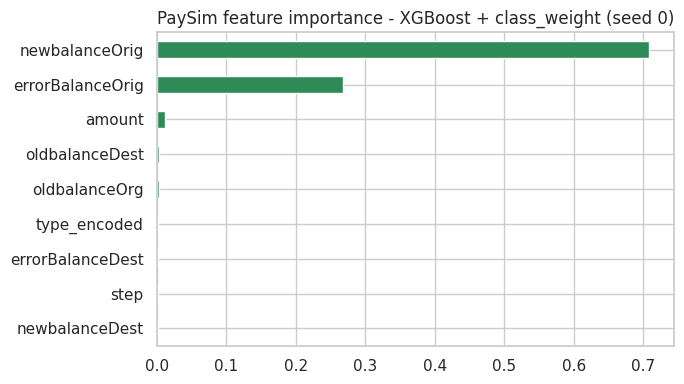

['/content/drive/MyDrive/Bicocca/Thesis code/results/paysim/xgb_class_weight_seed0.joblib']

In [6]:
best_label_ps = paysim_results_df.loc[paysim_results_df["f1_mean"].idxmax(), "strategy"]
best_model_ps = paysim_models[(best_label_ps, 0)]

importances = pd.Series(best_model_ps.feature_importances_, index=feature_cols)
plt.figure(figsize=(7, 4))
importances.sort_values().plot(kind="barh", color="seagreen")
plt.title(f"PaySim feature importance - XGBoost + {best_label_ps} (seed 0)")
plt.tight_layout()
plt.savefig(PAYSIM_FIGDIR / "paysim_feature_importance.png", dpi=150)
plt.show()

joblib.dump(best_model_ps, PAYSIM_OUTDIR / f"xgb_{best_label_ps}_seed0.joblib")

---
# Part B — BAF (Bank Account Fraud, Base variant)

**Dataset:** https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022
Target column: `fraud_bool`. The dataset spans 8 simulated months (`month`
0-7); its original paper recommends training on months 0-5, validating on
month 6, and testing on month 7 - used here instead of a fresh percentage
split, since it is the dataset's own documented evaluation protocol.


## B.0 Config

In [7]:
BAF_PATH = BASE / 'data' / 'raw' / 'baf' / 'Base.csv'   # rename if your file differs

BAF_OUTDIR = BASE / 'results' / 'baf'
BAF_FIGDIR = BAF_OUTDIR / 'figures'
for p in [BAF_OUTDIR, BAF_FIGDIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Looking for data at:', BAF_PATH)
print('Exists:', BAF_PATH.exists())

Looking for data at: /content/drive/MyDrive/Bicocca/Thesis code/data/raw/baf/Base.csv
Exists: True


## B.1 Load and inspect

In [8]:
df_baf = pd.read_csv(BAF_PATH)
print(f"Shape: {df_baf.shape}")

assert "fraud_bool" in df_baf.columns, "Expected target column 'fraud_bool' not found - check the file."
print(f"Fraud rate: {df_baf['fraud_bool'].mean()*100:.3f}%  ({df_baf['fraud_bool'].sum():,} / {len(df_baf):,})")

if "month" in df_baf.columns:
    print("\nRows per month:")
    print(df_baf["month"].value_counts().sort_index())
else:
    print("\nNo 'month' column found - will fall back to a random 70/10/20 split instead of the")
    print("dataset's documented temporal protocol.")

Shape: (1000000, 32)
Fraud rate: 1.103%  (11,029 / 1,000,000)

Rows per month:
month
0    132440
1    127620
2    136979
3    150936
4    127691
5    119323
6    108168
7     96843
Name: count, dtype: int64


## B.2 Preprocessing and split

Categorical columns are label-encoded (with a "missing" fallback for NaNs);
BAF's numeric columns are engineered features already provided by the
dataset (velocity windows, risk scores, etc.), so no additional feature
engineering is added here - the point of this section is testing transfer
of the *modeling* approach, not re-doing feature engineering from scratch a
third time.

In [9]:
target_col = "fraud_bool"
exclude_cols = [target_col]
if "month" in df_baf.columns:
    exclude_cols.append("month")

categorical_cols = df_baf.drop(columns=exclude_cols).select_dtypes(include="object").columns.tolist()
numeric_cols = [c for c in df_baf.columns
                if c not in exclude_cols + categorical_cols]

print("Categorical columns:", categorical_cols)
print(f"Numeric columns: {len(numeric_cols)}")

df_baf_enc = df_baf.copy()
for col in categorical_cols:
    df_baf_enc[col] = df_baf_enc[col].fillna("missing").astype(str)
    df_baf_enc[col] = LabelEncoder().fit_transform(df_baf_enc[col])

for col in numeric_cols:
    df_baf_enc[col] = df_baf_enc[col].fillna(df_baf_enc[col].median())

baf_feature_cols = categorical_cols + numeric_cols

if "month" in df_baf_enc.columns:
    train_baf = df_baf_enc[df_baf_enc["month"] <= 5]
    val_baf = df_baf_enc[df_baf_enc["month"] == 6]
    test_baf = df_baf_enc[df_baf_enc["month"] == 7]
else:
    df_baf_enc = df_baf_enc.sample(frac=1.0, random_state=42).reset_index(drop=True)
    n = len(df_baf_enc)
    n_test = int(n * 0.2)
    n_val = int(n * 0.1)
    train_baf = df_baf_enc.iloc[:n - n_test - n_val]
    val_baf = df_baf_enc.iloc[n - n_test - n_val:n - n_test]
    test_baf = df_baf_enc.iloc[n - n_test:]

print(f"Train: {len(train_baf):,} ({train_baf[target_col].mean()*100:.3f}% fraud)")
print(f"Val:   {len(val_baf):,} ({val_baf[target_col].mean()*100:.3f}% fraud)")
print(f"Test:  {len(test_baf):,} ({test_baf[target_col].mean()*100:.3f}% fraud)")

X_train_baf, y_train_baf = train_baf[baf_feature_cols], train_baf[target_col]
X_test_baf, y_test_baf = test_baf[baf_feature_cols], test_baf[target_col]

Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
Numeric columns: 25
Train: 794,989 (1.025% fraud)
Val:   108,168 (1.341% fraud)
Test:  96,843 (1.475% fraud)


## B.3 Train XGBoost (none / class_weight) and evaluate, repeated across 3 seeds

Same repeated-seed protocol as Part A.3 above: seeds 0, 1, 2 per strategy,
aggregated to mean $\pm$ std with the same `<metric>_mean` / `<metric>_std`
column convention.

In [10]:
baf_results_raw = []
baf_models = {}  # keyed by (label, seed)

for use_cw in [False, True]:
    label = "class_weight" if use_cw else "none"
    for seed in SEEDS:
        t0 = time.time()
        model = train_xgb(X_train_baf, y_train_baf, use_cw, seed=seed)
        train_time = time.time() - t0

        y_pred = model.predict(X_test_baf)
        y_score = model.predict_proba(X_test_baf)[:, 1]
        m = evaluate(y_test_baf, y_pred, y_score)
        m.update({"strategy": label, "seed": seed, "train_time_s": train_time, "domain": "BAF"})
        baf_results_raw.append(m)
        baf_models[(label, seed)] = model
        print(f"{label} (seed={seed}): precision={m['precision']:.4f} recall={m['recall']:.4f} "
              f"f1={m['f1']:.4f} pr_auc={m['pr_auc']:.4f} roc_auc={m['roc_auc']:.4f}")

baf_raw_df = pd.DataFrame(baf_results_raw)
baf_raw_df.to_csv(BAF_OUTDIR / "rq5_baf_results_raw.csv", index=False)

baf_agg = baf_raw_df.groupby("strategy")[metric_cols].agg(["mean", "std"])
baf_agg.columns = [f"{m}_{stat}" for m, stat in baf_agg.columns]
baf_agg = baf_agg.fillna(0.0).reset_index()
baf_agg.insert(1, "domain", "BAF")

baf_results_df = baf_agg  # kept as `baf_results_df` so Part C below is unchanged
baf_results_df.to_csv(BAF_OUTDIR / "rq5_baf_results.csv", index=False)
baf_results_df

none (seed=0): precision=0.5604 recall=0.0357 f1=0.0671 pr_auc=0.2000 roc_auc=0.8882
none (seed=1): precision=0.5604 recall=0.0357 f1=0.0671 pr_auc=0.2000 roc_auc=0.8882
none (seed=2): precision=0.5604 recall=0.0357 f1=0.0671 pr_auc=0.2000 roc_auc=0.8882
class_weight (seed=0): precision=0.1042 recall=0.5917 f1=0.1772 pr_auc=0.1650 roc_auc=0.8727
class_weight (seed=1): precision=0.1042 recall=0.5917 f1=0.1772 pr_auc=0.1650 roc_auc=0.8727
class_weight (seed=2): precision=0.1042 recall=0.5917 f1=0.1772 pr_auc=0.1650 roc_auc=0.8727


,strategy,domain,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,train_time_s_mean,train_time_s_std
0,class_weight,BAF,0.104205,0.0,0.591737,0.0,0.177205,0.0,0.164988,0.0,0.872684,0.0,34.78840,1.357917
1,none,BAF,0.560440,0.0,0.035714,0.0,0.067149,0.0,0.199960,0.0,0.888209,0.0,35.39118,1.500132


## B.4 Feature importance on BAF

Uses the seed-0 model for the strategy with the highest mean F1 (same
convention as A.4).

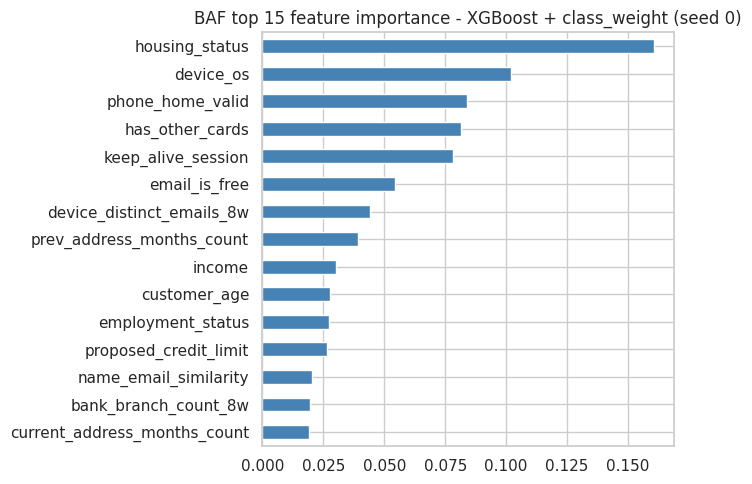

['/content/drive/MyDrive/Bicocca/Thesis code/results/baf/xgb_class_weight_seed0.joblib']

In [11]:
best_label_baf = baf_results_df.loc[baf_results_df["f1_mean"].idxmax(), "strategy"]
best_model_baf = baf_models[(best_label_baf, 0)]

importances_baf = pd.Series(best_model_baf.feature_importances_, index=baf_feature_cols)
top15_baf = importances_baf.sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 5))
top15_baf.sort_values().plot(kind="barh", color="steelblue")
plt.title(f"BAF top 15 feature importance - XGBoost + {best_label_baf} (seed 0)")
plt.tight_layout()
plt.savefig(BAF_FIGDIR / "baf_feature_importance.png", dpi=150)
plt.show()

joblib.dump(best_model_baf, BAF_OUTDIR / f"xgb_{best_label_baf}_seed0.joblib")

---
# Part C — Combined Transferability Table

Brings together the Credit Card baseline (Section 4.2's XGBoost + class
weighting result, mean $\pm$ std across the same 3 seeds, already
established in Table 4.1), PaySim, and BAF into one table, and computes
**retention** = new-domain mean metric / Credit Card mean metric, which
gives RQ5 a single number per domain instead of just a qualitative
impression. Retention is computed on the mean estimates; the std columns
are carried through unchanged so the final table can still report
mean $\pm$ std per domain.

In [12]:
# Credit Card, XGBoost + class_weight, mean +/- std across seeds 0/1/2
# (identical numbers already reported in Table 4.1 / Section 4.2).
CREDIT_CARD_BASELINE = {
    "domain": "Credit Card",
    "strategy": "class_weight",
    "precision_mean": 0.8730, "precision_std": 0.0000,
    "recall_mean": 0.7333,    "recall_std": 0.0000,
    "f1_mean": 0.7971,        "f1_std": 0.0000,
    "pr_auc_mean": 0.7875,    "pr_auc_std": 0.0000,
    "roc_auc_mean": 0.9851,   "roc_auc_std": 0.0000,
    "train_time_s_mean": 11.12, "train_time_s_std": 1.33,
}

rows = [CREDIT_CARD_BASELINE]

# Reload from disk so Part C works even in a fresh session where Parts A/B
# already ran earlier and saved their CSVs.
if (PAYSIM_OUTDIR / "rq5_paysim_results.csv").exists():
    _ps = pd.read_csv(PAYSIM_OUTDIR / "rq5_paysim_results.csv")
    _ps_best = _ps.loc[_ps["f1_mean"].idxmax()].to_dict()
    rows.append(_ps_best)
else:
    print("PaySim results not found yet - run Part A first.")

if (BAF_OUTDIR / "rq5_baf_results.csv").exists():
    _baf = pd.read_csv(BAF_OUTDIR / "rq5_baf_results.csv")
    _baf_best = _baf.loc[_baf["f1_mean"].idxmax()].to_dict()
    rows.append(_baf_best)
else:
    print("BAF results not found yet - run Part B first.")

metric_names = ["precision", "recall", "f1", "pr_auc", "roc_auc"]
keep_cols = ["domain", "strategy"] + [f"{m}_{s}" for m in metric_names for s in ("mean", "std")]
transfer_df = pd.DataFrame(rows)[keep_cols]

cc_row = transfer_df[transfer_df["domain"] == "Credit Card"].iloc[0]
for metric in metric_names:
    transfer_df[f"{metric}_retention"] = transfer_df[f"{metric}_mean"] / cc_row[f"{metric}_mean"]

transfer_df.round(4)

,domain,strategy,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_retention,recall_retention,f1_retention,pr_auc_retention,roc_auc_retention
0,Credit Card,class_weight,0.8730,0.0,0.7333,0.0,0.7971,0.0,0.7875,0.0,0.9851,0.0,1.0000,1.0000,1.0000,1.0000,1.0000
1,PaySim,class_weight,0.9909,0.0,0.9974,0.0,0.9941,0.0,0.9993,0.0,1.0000,0.0,1.1350,1.3602,1.2472,1.2689,1.0151
2,BAF,class_weight,0.1042,0.0,0.5917,0.0,0.1772,0.0,0.1650,0.0,0.8727,0.0,0.1194,0.8070,0.2223,0.2095,0.8859


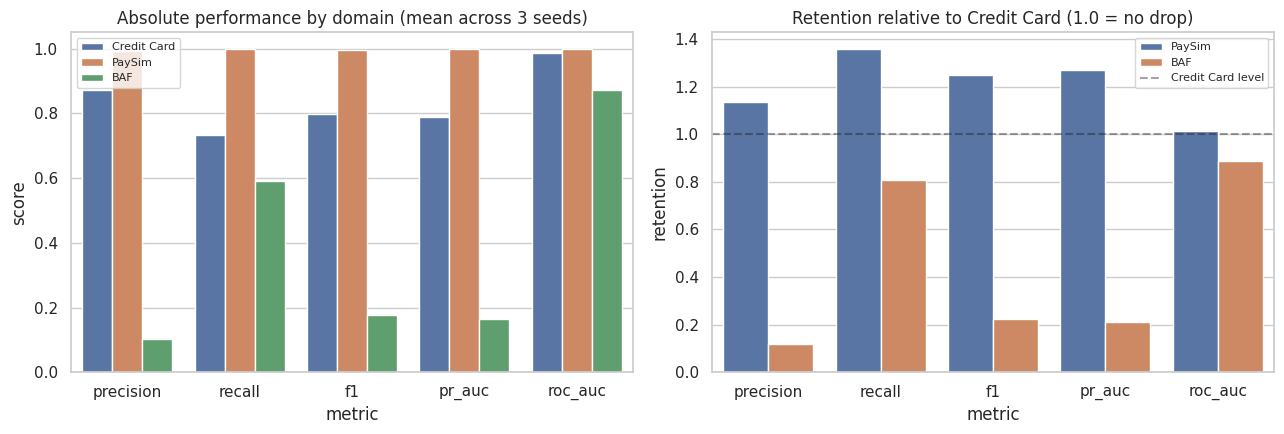


Saved combined summary to /content/drive/MyDrive/Bicocca/Thesis code/results/rq5_transferability_summary.csv


In [13]:
RESULTS_ROOT = BASE / 'results'
transfer_df.to_csv(RESULTS_ROOT / "rq5_transferability_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

mean_cols = [f"{m}_mean" for m in metric_names]
plot_df = transfer_df.melt(id_vars="domain", value_vars=mean_cols,
                            var_name="metric", value_name="score")
plot_df["metric"] = plot_df["metric"].str.replace("_mean", "")
sns.barplot(data=plot_df, x="metric", y="score", hue="domain", ax=axes[0])
axes[0].set_title("Absolute performance by domain (mean across 3 seeds)")
axes[0].legend(fontsize=8)

retention_cols = [c for c in transfer_df.columns if c.endswith("_retention")]
retention_plot = transfer_df.melt(id_vars="domain", value_vars=retention_cols,
                                   var_name="metric", value_name="retention")
retention_plot["metric"] = retention_plot["metric"].str.replace("_retention", "")
sns.barplot(data=retention_plot[retention_plot["domain"] != "Credit Card"],
            x="metric", y="retention", hue="domain", ax=axes[1])
axes[1].axhline(1.0, color="k", linestyle="--", alpha=0.4, label="Credit Card level")
axes[1].set_title("Retention relative to Credit Card (1.0 = no drop)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_ROOT / "rq5_transferability.png", dpi=150)
plt.show()

print(f"\nSaved combined summary to {RESULTS_ROOT / 'rq5_transferability_summary.csv'}")